In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
from pathlib import Path

DATASET_DIR = Path("/content/drive/MyDrive/Healthy-Unhealthy-Plant.v1i.yolov11")

print(DATASET_DIR)
print("Exists:", DATASET_DIR.exists())
print("Files:", os.listdir(DATASET_DIR))


/content/drive/MyDrive/Healthy-Unhealthy-Plant.v1i.yolov11
Exists: True
Files: ['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'valid', 'train', 'test']


In [4]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.6 MB/s eta 0:00:00


In [5]:
from pathlib import Path

DATASET_DIR = Path("/content/drive/MyDrive/Healthy-Unhealthy-Plant.v1i.yolov11")
print("Dataset exists:", DATASET_DIR.exists())


Dataset exists: True


In [6]:
print(list(DATASET_DIR.glob("*.yaml")))


[PosixPath('/content/drive/MyDrive/Healthy-Unhealthy-Plant.v1i.yolov11/data.yaml')]


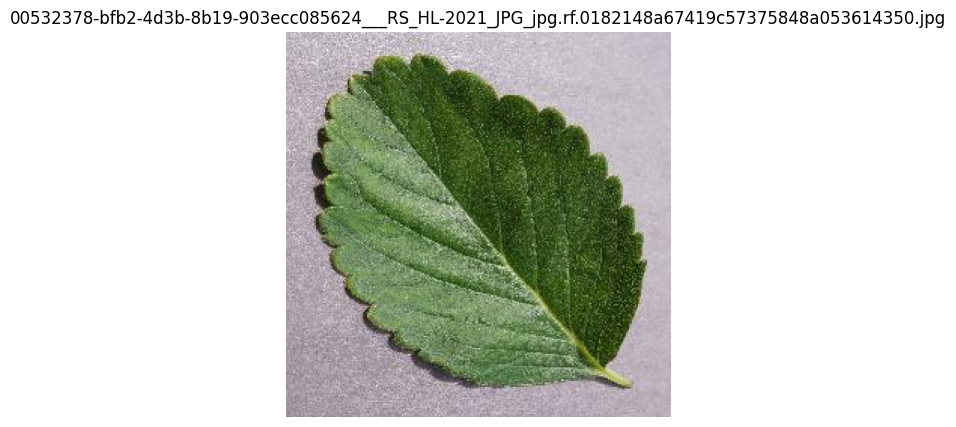

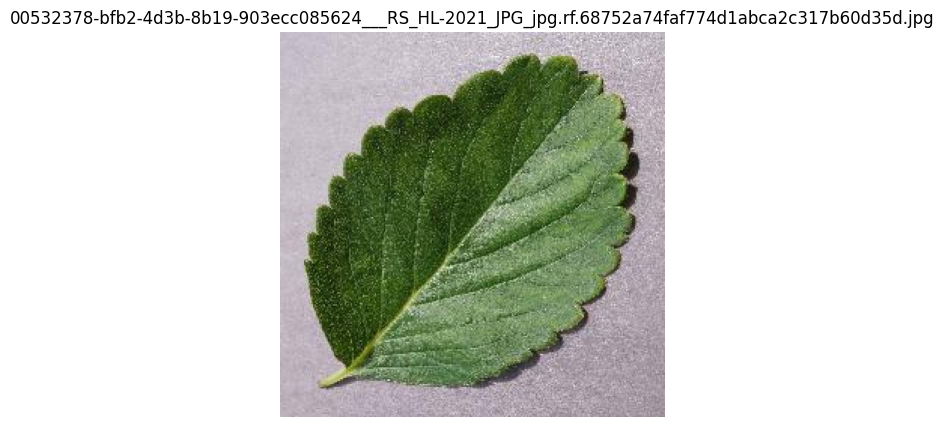

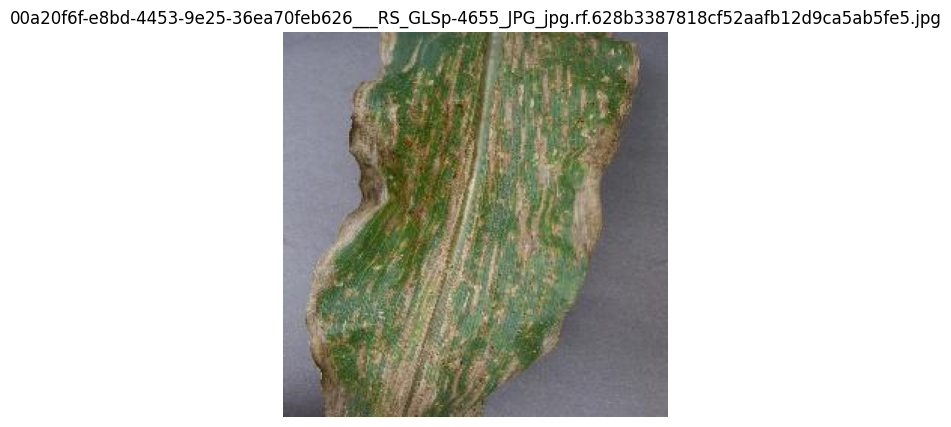

In [7]:
import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path

DATASET_DIR = Path("/content/drive/MyDrive/Healthy-Unhealthy-Plant.v1i.yolov11")

images_dir = DATASET_DIR / "train" / "images"

# Show first 3 images
sample_images = sorted(os.listdir(images_dir))[:3]

for img_name in sample_images:
    img_path = str(images_dir / img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")


In [8]:
labels_dir = DATASET_DIR / "train" / "labels"

for img_name in sample_images:
    label_path = labels_dir / img_name.replace(".jpg", ".txt").replace(".png", ".txt")

    print("Labels for:", img_name)
    if label_path.exists():
        print(label_path.read_text())
    else:
        print("NO LABEL FILE FOUND!")
    print("-" * 50)


Labels for: 00532378-bfb2-4d3b-8b19-903ecc085624___RS_HL-2021_JPG_jpg.rf.0182148a67419c57375848a053614350.jpg
0 0.5140625 0.5015625 0.85625 0.8640625
--------------------------------------------------
Labels for: 00532378-bfb2-4d3b-8b19-903ecc085624___RS_HL-2021_JPG_jpg.rf.68752a74faf774d1abca2c317b60d35d.jpg
0 0.4859375 0.5015625 0.85625 0.8640625
--------------------------------------------------
Labels for: 00a20f6f-e8bd-4453-9e25-36ea70feb626___RS_GLSp-4655_JPG_jpg.rf.628b3387818cf52aafb12d9ca5ab5fe5.jpg
1 0.484375 0.5015625 0.8515625 0.996875
--------------------------------------------------


In [9]:
yaml_path = DATASET_DIR / "data.yaml"
print(yaml_path.read_text())


train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['Healthy Plant', 'Unhealthy Plant']

roboflow:
  workspace: testing-au1l8
  project: healthy-unhealthy-plant-zr1bj
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/testing-au1l8/healthy-unhealthy-plant-zr1bj/dataset/1


In [11]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")  # small model

# Just validate dataset structure
model.val(data=str(yaml_path))

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 0.2±0.1 MB/s, size: 60.7 KB)
val: Scanning /content/drive/MyDrive/Healthy-Unhealthy-Plant.v1i.yolov11/valid/labels... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 1.4it/s 21.1s
val: New cache created: /content/drive/MyDrive/Healthy-Unhealthy-Plant.v1i.yolov11/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.0it/s 1.9s
                   all         30         36      0.274      0.329      0.215       0.16
                person         12         15     0.0483      0.467       0.11     0.0805
               bicycle         20         21        0.5       0.19       0.32       0.24
Speed: 3.6ms preprocess, 11.3ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x788efbe1d970>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [12]:
!pip install ultralytics


In [ ]:
from ultralytics import YOLO
from pathlib import Path

DATASET_DIR = Path("/content/drive/MyDrive/Healthy-Unhealthy-Plant.v1i.yolov11")
yaml_path = DATASET_DIR / "data.yaml"

# Load model
model = YOLO("yolo11s.pt")

# Train
model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=8,
    project="plant_health",
    name="yolo11_train",
)


Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Healthy-Unhealthy-Plant.v1i.yolov11/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo11_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat